# Loading libs

In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# Import dataset into workspace

In [ ]:
filepath = "../data/covid19_data/full_grouped.csv"
data = pd.read_csv(filepath)

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


# Dataset info

In [19]:
data.head()

,Date,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,WHO Region
0,2020-01-22,Afghanistan,0,0,0,0,0,0,0,Eastern Mediterranean
1,2020-01-22,Albania,0,0,0,0,0,0,0,Europe
2,2020-01-22,Algeria,0,0,0,0,0,0,0,Africa
3,2020-01-22,Andorra,0,0,0,0,0,0,0,Europe
4,2020-01-22,Angola,0,0,0,0,0,0,0,Africa


In [22]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Confirmed,35156.0,23566.631073,149981.835259,0.0,1.0,250.0,3640.25,4290259.0
Deaths,35156.0,1234.068239,7437.238354,0.0,0.0,4.0,78.25,148011.0
Recovered,35156.0,11048.134856,64546.400787,0.0,0.0,33.0,1286.25,1846641.0
Active,35156.0,11284.427978,89971.494115,-2.0,0.0,85.0,1454.00,2816444.0
New cases,35156.0,469.363750,3005.867540,0.0,0.0,2.0,75.00,77255.0
New deaths,35156.0,18.603339,115.706351,-1918.0,0.0,0.0,1.00,3887.0
New recovered,35156.0,269.315593,2068.063852,-16298.0,0.0,0.0,20.00,140050.0


In [26]:
data.shape

(35156, 10)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35156 entries, 0 to 35155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            35156 non-null  object
 1   Country/Region  35156 non-null  object
 2   Confirmed       35156 non-null  int64 
 3   Deaths          35156 non-null  int64 
 4   Recovered       35156 non-null  int64 
 5   Active          35156 non-null  int64 
 6   New cases       35156 non-null  int64 
 7   New deaths      35156 non-null  int64 
 8   New recovered   35156 non-null  int64 
 9   WHO Region      35156 non-null  object
dtypes: int64(7), object(3)
memory usage: 2.7+ MB


In [27]:
data["Country/Region"].count()

np.int64(35156)

In [ ]:
data.isna().sum()

In [37]:
country_totals = data.groupby('Country/Region')[['Confirmed', 'Deaths', 'Recovered']].sum()
country_totals.values

array([[  1936390,     49098,    798240],
       [   196702,      5708,    118877],
       [  1179755,     77972,    755897],
       [    94404,      5423,     69074],
       [    22662,      1078,      6573],
       [     4487,       326,      2600],
       [  4450658,     97749,   1680024],
       [  1587173,     27089,    857482],
       [   960247,     11387,    711928],
       [  2034986,     71390,   1638380],
       [  1134717,     14282,    703402],
       [    12100,      1203,      6047],
       [  1755206,      5115,   1334787],
       [  8754729,    115633,   3714702],
       [    10652,       738,      7444],
       [  4426759,     28391,   2771925],
       [  6281116,    963679,   1627492],
       [     2636,       222,      1618],
       [    64406,      1095,     25911],
       [     4971,         0,      2838],
       [  2170351,     78032,    571653],
       [   396634,     16373,    207156],
       [    15306,       120,      2291],
       [ 89524967,   3938034,  544

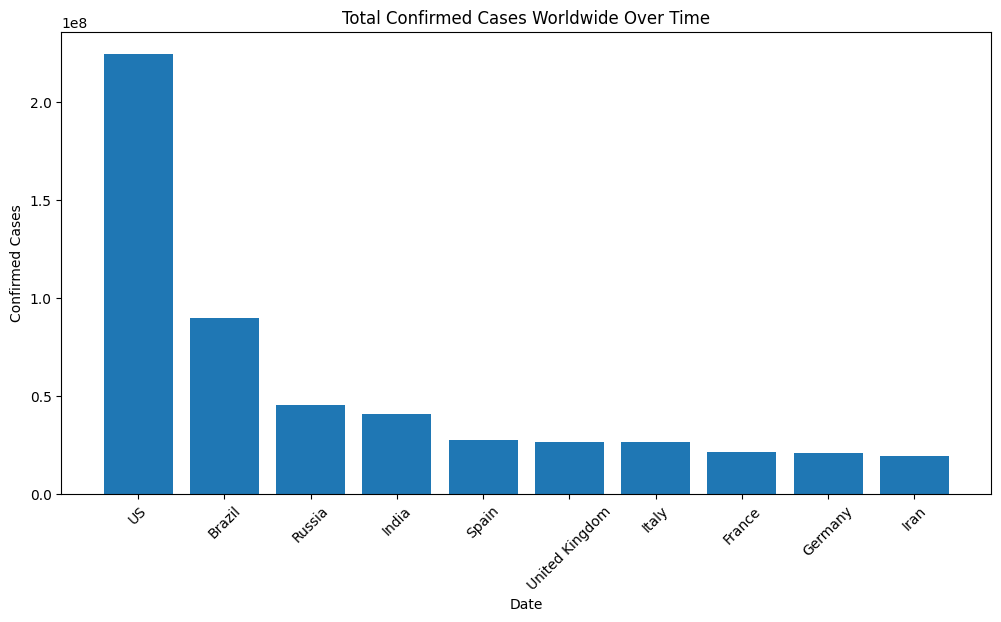

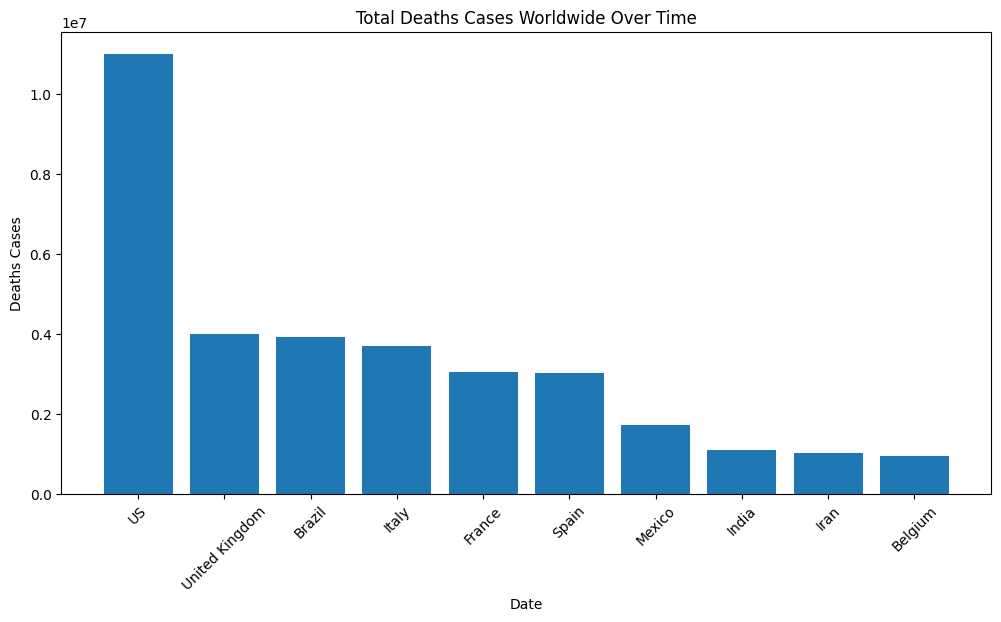

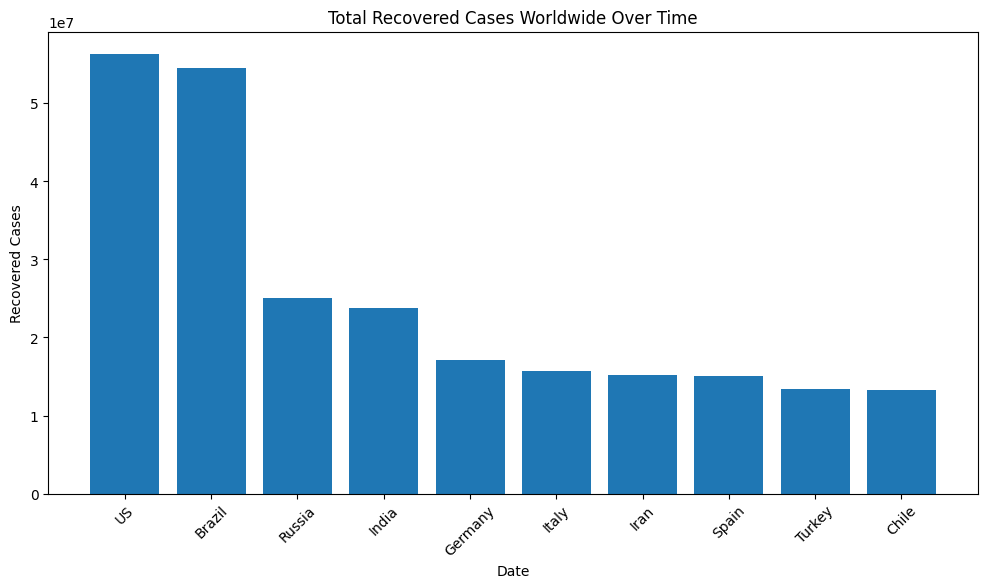

In [35]:
cols = ['Confirmed', 'Deaths', 'Recovered']

for col in cols:
    work = data.groupby('Country/Region')[col].sum().sort_values(ascending=False)

    plt.figure(figsize=(12,6))
    plt.bar(
    work[:10].index , work[:10].values)
    plt.title(f'Total {col} Cases Worldwide Over Time')
    plt.xlabel('Date')
    plt.ylabel(f'{col} Cases')
    plt.xticks(rotation=45)
    plt.show()


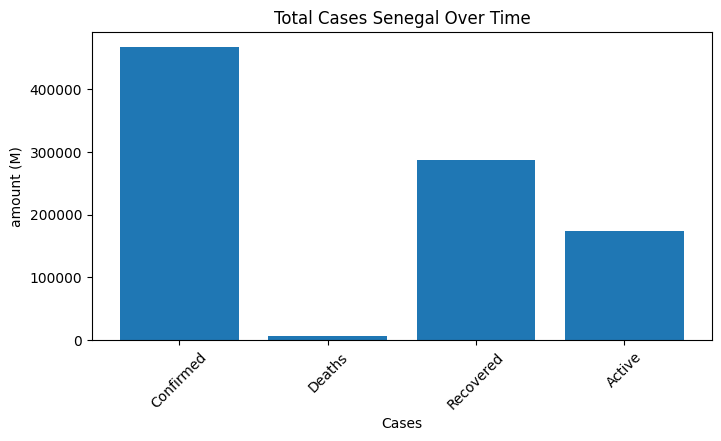

In [ ]:
cols = ['Confirmed', 'Deaths', 'Recovered', 'Active']

senegal_data = data[data["Country/Region"] == "Senegal"][cols].sum()
senegal_data

plt.figure(figsize=(8, 4))
plt.bar(cols , senegal_data)
plt.title(f'Total Cases Senegal Over Time')
plt.xlabel('Cases')
plt.ylabel(f'amount (M)')
plt.xticks(rotation=45)
plt.show()

In [78]:
date = data['Date'] = pd.to_datetime(data['Date'])
date

0       2020-01-22
1       2020-01-22
2       2020-01-22
3       2020-01-22
4       2020-01-22
           ...    
35151   2020-07-27
35152   2020-07-27
35153   2020-07-27
35154   2020-07-27
35155   2020-07-27
Name: Date, Length: 35156, dtype: datetime64[ns]

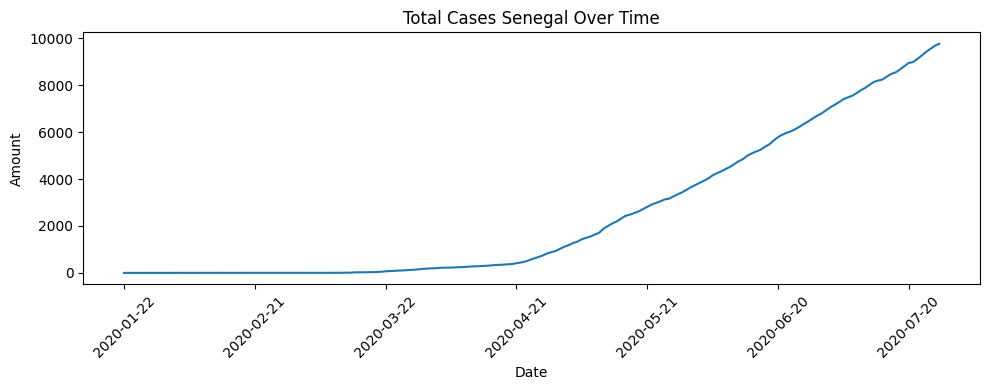

In [79]:
senegal_data = data[data["Country/Region"] == "Senegal"].groupby('Date')["Confirmed"].sum()

plt.figure(figsize=(10, 4))
plt.plot(senegal_data.index, senegal_data.values)
plt.title('Total Cases Senegal Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')

# Afficher 1 date sur 30 par exemple
dates = senegal_data.index
plt.xticks(dates[::30], rotation=45)

plt.tight_layout()
plt.show()